# $\mathbb{Z}_2^F \times \mathbb{Z}_2^T$ Hamiltonians - check states

Created: 15-07-2026

Objectives:
* Check the states that were saved [here](../../save_states/z2_f_x_z2_t_hamiltonians.ipynb).

# Imports

In [1]:
from time import time

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
from tqdm import tqdm

In [66]:
from functools import reduce
from itertools import product, combinations_with_replacement

In [6]:
import quimb.tensor as qtn
import quimb as qu

In [7]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d, spinless_fermion_basis_1d, tensor_basis

In [8]:
from humanize import naturalsize

In [9]:
TOP_DATA_DIR = r"../../data/"
TRIV_COCYCLE_DIR = TOP_DATA_DIR + r"z2_f_x_z2_t_triv_to_nontriv_n1_10_site_ed"
NONTRIV_COCYCLE_DIR = TOP_DATA_DIR + r"z2_f_x_z2_t_nontriv_n1_to_nontriv_cocyle_10_site_ed"

# Import states

In [10]:
test = np.load(rf'{TRIV_COCYCLE_DIR}/0.npz')

In [11]:
test['energy']

array([-10.])

In [12]:
test['psi'].shape

(1048576, 1)

In [13]:
triv_cocycle_data = [
    np.load(rf'{TRIV_COCYCLE_DIR}/{i}.npz')
    for i in range(0, 101, 5)
]

In [14]:
nontriv_cocycle_data = [
    np.load(rf'{NONTRIV_COCYCLE_DIR}/{i}.npz')
    for i in range(0, 101, 5)
]

In [15]:
len(triv_cocycle_data), len(nontriv_cocycle_data),

(21, 21)

# Definitions

In [16]:
L = 10

In [17]:
spin_basis = spin_basis_1d(L)
fermion_basis = spinless_fermion_basis_1d(L)
basis = tensor_basis(spin_basis, fermion_basis)

In [18]:
print(basis)

reference states: 
array index   /   Fock state   /   integer repr. 
	      0.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 1 1 1>  1023 
	      1.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 1 1 0>  1022 
	      2.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 1 0 1>  1021 
	      3.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 1 0 0>  1020 
	      4.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 0 1 1>  1019 
	      5.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 0 1 0>  1018 
	      6.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 0 0 1>  1017 
	      7.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 0 0 0>  1016 
	      8.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 0 1 1 1>  1015 
	      9.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 0 1 1 0>  1014 
	     10.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 0 1 0 1>  1013 
	     11.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 0 1 0 0>  1012 
	     12.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 0 0 1 1>  1011 
	     13.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1

# Analysis

## Energies

In [19]:
triv_energies = [x['energy'] for x in triv_cocycle_data]

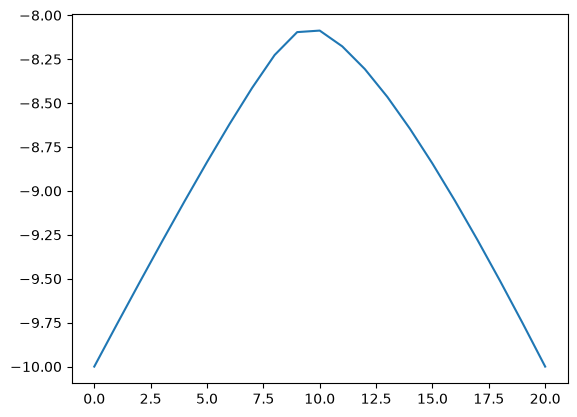

In [20]:
plt.plot(triv_energies)

In [21]:
nontriv_energies = [x['energy'] for x in nontriv_cocycle_data]

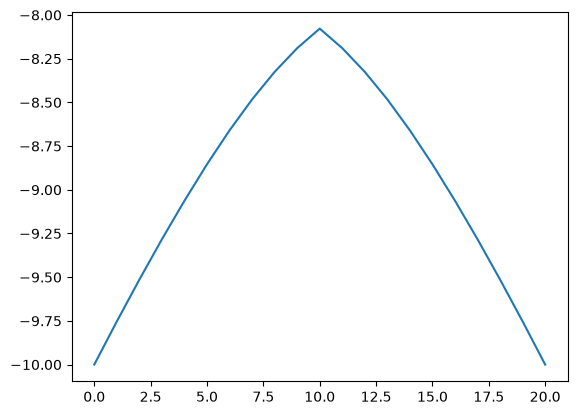

In [22]:
plt.plot(nontriv_energies)

## Check $T=XK$ symmetry

In [23]:
x_sym = quantum_operator(
    {"x": [["x"*L + "|", [[1, *list(range(L))]]]]},
    basis=basis,
    dtype=np.complex128
)

Hermiticity check passed!


/tmp/ipykernel_22077/1830159187.py:1: UserWarning: Test for symmetries not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_symm=False in hamiltonian
  x_sym = quantum_operator(
/tmp/ipykernel_22077/1830159187.py:1: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  x_sym = quantum_operator(


In [24]:
psi = triv_cocycle_data[0]['psi']

In [25]:
psi.shape

(1048576, 1)

In [26]:
naturalsize(psi.nbytes)

'16.8 MB'

In [27]:
sym_psi = psi.conj()

In [28]:
np.sum(sym_psi.conj()*sym_psi)

np.complex128(0.9999999999999989+3.736841586472211e-20j)

In [29]:
np.sum(psi.conj()*psi)

np.complex128(0.9999999999999989-3.736841586472211e-20j)

In [30]:
np.abs(np.sum(sym_psi.conj()*psi))

np.float64(0.020253456384014455)

## Expectation values

In [43]:
one_site_paulis = [
    quantum_operator(
        {s: [[f"{s}|" , [[1, 0]]]]},
        basis=basis,
        dtype=np.complex128
    )
    for s in "xyz"
]

Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!


/tmp/ipykernel_22077/4294405670.py:2: UserWarning: Test for symmetries not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_symm=False in hamiltonian
  quantum_operator(
/tmp/ipykernel_22077/4294405670.py:2: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  quantum_operator(


In [44]:
one_site_fermion_occupation = quantum_operator(
    {"n": [["|n" , [[1, 0]]]]},
    basis=basis,
    dtype=np.complex128
)

Hermiticity check passed!


/tmp/ipykernel_22077/2974233378.py:1: UserWarning: Test for symmetries not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_symm=False in hamiltonian
  one_site_fermion_occupation = quantum_operator(
/tmp/ipykernel_22077/2974233378.py:1: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  one_site_fermion_occupation = quantum_operator(


In [45]:
triv_groundstates = [
    x['psi'] for x in triv_cocycle_data
]

nontriv_groundstates = [
    x['psi'] for x in nontriv_cocycle_data
]

In [46]:
triv_pauli_expectations = np.array([
    [op.expt_value(psi) for psi in triv_groundstates]
    for op in one_site_paulis
])

nontriv_pauli_expectations = np.array([
    [op.expt_value(psi) for psi in nontriv_groundstates]
    for op in one_site_paulis
])

In [47]:
np.round(triv_pauli_expectations, 3)

array([[[ 0.   +0.j],
        [-0.   +0.j],
        [-0.   +0.j],
        [ 0.   +0.j],
        [ 0.   +0.j],
        [-0.   -0.j],
        [ 0.   +0.j],
        [ 0.   -0.j],
        [-0.   +0.j],
        [-0.   +0.j],
        [-0.   +0.j],
        [ 0.   +0.j],
        [-0.   -0.j],
        [-0.   +0.j],
        [-0.   +0.j],
        [ 0.   +0.j],
        [ 0.   -0.j],
        [ 0.   -0.j],
        [-0.   -0.j],
        [ 0.   -0.j],
        [-0.   -0.j]],

       [[ 0.   +0.j],
        [-0.   -0.j],
        [ 0.   +0.j],
        [ 0.   -0.j],
        [-0.   -0.j],
        [ 0.   -0.j],
        [ 0.   -0.j],
        [ 0.   +0.j],
        [ 0.   -0.j],
        [ 0.   +0.j],
        [-0.   -0.j],
        [ 0.   -0.j],
        [ 0.   +0.j],
        [ 0.   -0.j],
        [ 0.   +0.j],
        [-0.   +0.j],
        [ 0.   -0.j],
        [ 0.   -0.j],
        [ 0.   -0.j],
        [-0.   +0.j],
        [ 0.   -0.j]],

       [[ 1.   +0.j],
        [ 1.   +0.j],
        [ 0.999+0.j],
      

In [51]:
parameters = np.linspace(0, 1, 21)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


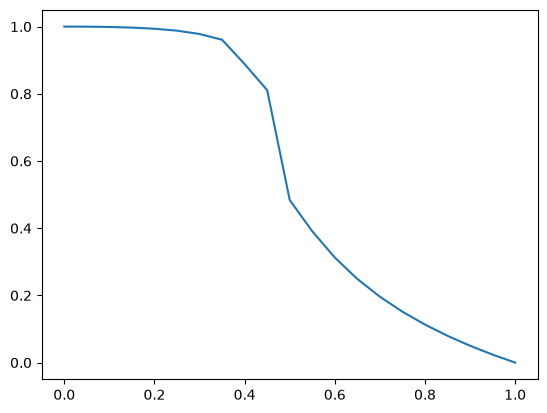

In [52]:
plt.plot(parameters, triv_pauli_expectations[2])

In [48]:
np.round(nontriv_pauli_expectations, 3)

array([[[-0.-0.j],
        [ 0.-0.j],
        [-0.-0.j],
        [ 0.+0.j],
        [-0.-0.j],
        [-0.-0.j],
        [ 0.+0.j],
        [-0.+0.j],
        [ 0.-0.j],
        [-0.+0.j],
        [-0.-0.j],
        [ 0.-0.j],
        [-0.+0.j],
        [-0.+0.j],
        [ 0.+0.j],
        [ 0.-0.j],
        [ 0.-0.j],
        [-0.+0.j],
        [ 0.+0.j],
        [ 0.+0.j],
        [ 0.-0.j]],

       [[-0.+0.j],
        [ 0.+0.j],
        [-0.-0.j],
        [ 0.-0.j],
        [-0.-0.j],
        [ 0.-0.j],
        [ 0.-0.j],
        [-0.-0.j],
        [ 0.-0.j],
        [-0.-0.j],
        [ 0.+0.j],
        [ 0.+0.j],
        [ 0.-0.j],
        [ 0.-0.j],
        [ 0.+0.j],
        [ 0.-0.j],
        [-0.+0.j],
        [ 0.-0.j],
        [-0.-0.j],
        [-0.+0.j],
        [ 0.-0.j]],

       [[ 0.+0.j],
        [-0.+0.j],
        [-0.+0.j],
        [ 0.+0.j],
        [-0.+0.j],
        [-0.+0.j],
        [ 0.+0.j],
        [-0.+0.j],
        [ 0.+0.j],
        [ 0.+0.j],
        

In [53]:
triv_fermion_occupations = np.array([
    one_site_fermion_occupation.expt_value(psi) for psi in triv_groundstates
])

nontriv_fermion_occupations = np.array([
    one_site_fermion_occupation.expt_value(psi) for psi in nontriv_groundstates
])

In [54]:
triv_fermion_occupations

array([[0.50358011+0.j],
       [0.95422147+0.j],
       [0.94972928+0.j],
       [0.94382679+0.j],
       [0.93592533+0.j],
       [0.92509945+0.j],
       [0.90985434+0.j],
       [0.88776309+0.j],
       [0.74526555+0.j],
       [0.70014816+0.j],
       [0.55861896+0.j],
       [0.53588136+0.j],
       [0.52193962+0.j],
       [0.51346953+0.j],
       [0.50818717+0.j],
       [0.50481894+0.j],
       [0.50266276+0.j],
       [0.50131192+0.j],
       [0.50051664+0.j],
       [0.50011553+0.j],
       [0.5       +0.j]])

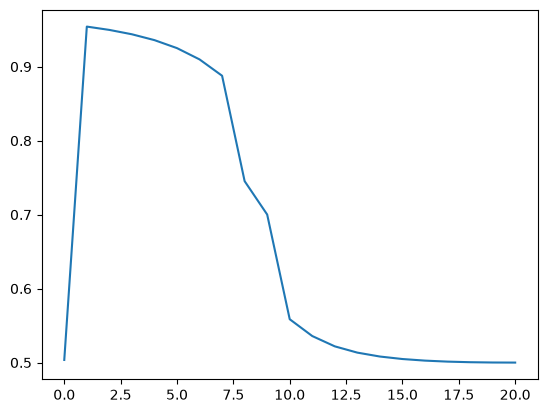

In [55]:
plt.plot(triv_fermion_occupations)

In [56]:
nontriv_fermion_occupations

array([[0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.53760871+0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j],
       [0.5       +0.j]])

Not sure if this looks right honestly?

In [57]:
two_site_paulis = [
    quantum_operator(
        {s: [[f"{s+s}|" , [[1, 0, 1]]]]},
        basis=basis,
        dtype=np.complex128
    )
    for s in "xyz"
]

Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!


/tmp/ipykernel_22077/3625545787.py:2: UserWarning: Test for symmetries not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_symm=False in hamiltonian
  quantum_operator(
/tmp/ipykernel_22077/3625545787.py:2: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  quantum_operator(


In [58]:
triv_two_site_pauli_expectations = np.array([
    [op.expt_value(psi) for psi in triv_groundstates]
    for op in two_site_paulis
])

nontriv_two_site_pauli_expectations = np.array([
    [op.expt_value(psi) for psi in nontriv_groundstates]
    for op in two_site_paulis
])

In [61]:
np.round(triv_two_site_pauli_expectations, 3)

array([[[-0.   +0.j],
        [-0.001+0.j],
        [-0.001+0.j],
        [-0.001-0.j],
        [ 0.   +0.j],
        [ 0.002-0.j],
        [ 0.004-0.j],
        [ 0.008-0.j],
        [-0.014-0.j],
        [-0.012-0.j],
        [-0.005-0.j],
        [-0.004+0.j],
        [-0.002+0.j],
        [-0.001+0.j],
        [-0.001+0.j],
        [-0.001-0.j],
        [-0.   +0.j],
        [-0.   -0.j],
        [-0.   +0.j],
        [-0.   +0.j],
        [-0.   -0.j]],

       [[ 0.   -0.j],
        [ 0.001-0.j],
        [ 0.002-0.j],
        [ 0.002+0.j],
        [ 0.003-0.j],
        [ 0.003+0.j],
        [ 0.004+0.j],
        [ 0.004+0.j],
        [ 0.026-0.j],
        [ 0.027+0.j],
        [ 0.003+0.j],
        [ 0.001+0.j],
        [ 0.001-0.j],
        [ 0.   +0.j],
        [ 0.   -0.j],
        [ 0.   -0.j],
        [ 0.   +0.j],
        [ 0.   +0.j],
        [ 0.   -0.j],
        [ 0.   -0.j],
        [ 0.   +0.j]],

       [[ 1.   +0.j],
        [ 1.   +0.j],
        [ 0.999+0.j],
      

In [62]:
np.round(nontriv_two_site_pauli_expectations, 3)

array([[[-0.   +0.j],
        [-0.   -0.j],
        [-0.   -0.j],
        [-0.   -0.j],
        [ 0.   -0.j],
        [ 0.   +0.j],
        [ 0.   -0.j],
        [ 0.   -0.j],
        [ 0.   +0.j],
        [-0.   +0.j],
        [-0.   -0.j],
        [ 0.   -0.j],
        [-0.   +0.j],
        [-0.   +0.j],
        [-0.   -0.j],
        [ 0.   +0.j],
        [ 0.   +0.j],
        [ 0.   +0.j],
        [-0.   +0.j],
        [-0.   +0.j],
        [ 0.   -0.j]],

       [[-0.   +0.j],
        [-0.   +0.j],
        [ 0.   -0.j],
        [-0.   +0.j],
        [ 0.   +0.j],
        [-0.   -0.j],
        [ 0.   +0.j],
        [ 0.   -0.j],
        [-0.   +0.j],
        [ 0.   -0.j],
        [-0.075+0.j],
        [ 0.   +0.j],
        [-0.   -0.j],
        [-0.   -0.j],
        [ 0.   +0.j],
        [ 0.   -0.j],
        [ 0.   +0.j],
        [-0.   -0.j],
        [-0.   -0.j],
        [ 0.   -0.j],
        [-0.   +0.j]],

       [[ 0.   +0.j],
        [-0.   +0.j],
        [ 0.   +0.j],
      

Are the nontrivial states just wrong?

In [64]:
overlaps = np.zeros((21, 21))

In [65]:
overlaps.shape

(21, 21)

In [70]:
for i, j in tqdm(combinations_with_replacement(range(21), 2)):
    overlap = np.abs(np.sum(nontriv_groundstates[i].conj() * nontriv_groundstates[j]))
    overlaps[i,j] = overlap
    overlaps[j,i] = overlap

231it [00:01, 162.92it/s]


In [71]:
np.round(overlaps, 3)

array([[1.   , 0.999, 0.996, 0.99 , 0.981, 0.966, 0.944, 0.915, 0.877,
        0.83 , 0.706, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   ],
       [0.999, 1.   , 0.999, 0.995, 0.988, 0.976, 0.957, 0.931, 0.895,
        0.851, 0.728, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   ],
       [0.996, 0.999, 1.   , 0.999, 0.994, 0.985, 0.969, 0.946, 0.914,
        0.873, 0.75 , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   ],
       [0.99 , 0.995, 0.999, 1.   , 0.998, 0.992, 0.981, 0.961, 0.933,
        0.896, 0.775, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   ],
       [0.981, 0.988, 0.994, 0.998, 1.   , 0.998, 0.99 , 0.976, 0.952,
        0.919, 0.8  , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   ],
       [0.966, 0.976, 0.985, 0.992, 0.998, 1.   , 0.997, 0.988, 0.97 ,
        0.943, 0.826, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   

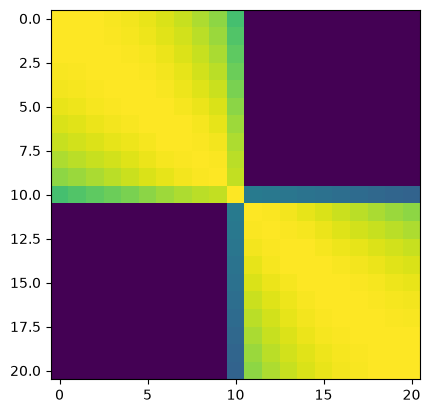

In [72]:
plt.imshow(overlaps)

Fascinating! Clear sign of a phase transition, I haven't seen this before. So something is changing!

# Conclusion
More or less ok, but weird things happening with expectations.